# Aperture photometry — brightnesses of stars in M67

We measure how bright stars are in a real CCD image by **aperture photometry**: sum
a star's light in a circle, subtract the sky from a surrounding annulus, convert to a
magnitude. We do it by hand and validate against `photutils`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
data = fits.getdata("data/real/m67_cutout.fits").astype(float)
print("image", data.shape, "median", np.median(data))

image (400, 400) median 3938.0


## 1. Look at the image

A real Palomar Schmidt frame of the open cluster M67. Always view with a stretch
(here √) so faint stars are visible alongside bright ones.

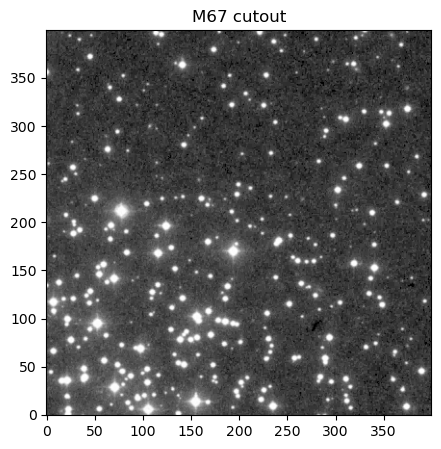

In [2]:
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(data, origin="lower", cmap="gray", norm=simple_norm(data,"sqrt",percent=99.5))
ax.set_title("M67 cutout"); plt.show()

## 2. Find the stars

`DAOStarFinder` locates point sources above the noise. We'll photometer the bright
ones. (Detecting sources is a separate skill; here it just gives us positions.)

In [3]:
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
_, med, std = sigma_clipped_stats(data, sigma=3.0)
found = DAOStarFinder(fwhm=4.0, threshold=20*std)(data - med)
found.sort("flux"); found.reverse()
pos = list(zip(found["x_centroid"][:15], found["y_centroid"][:15]))
print(len(found), "sources;", "measuring 15 brightest")

163 sources; measuring 15 brightest


## 3. Measure one star, by hand

Sum the pixels in a circular aperture, estimate the sky from the median of an
annulus, subtract. This is the whole idea of aperture photometry in three lines.

In [4]:
from scripts.photometry import aperture_flux, instrumental_mag
x, y = pos[0]
flux = aperture_flux(data, x, y, r=6.0, r_in=10.0, r_out=15.0)
print(f"star at ({x:.1f},{y:.1f}): net flux = {flux:.0f}, inst. mag = {instrumental_mag(flux):.3f}")

star at (21.7,19.1): net flux = 205604, inst. mag = 11.717


## 4. Cross-check against photutils

Our hand-rolled aperture sum must match the standard library. Using
`method='center'` (count whole pixels whose center is inside) — the same rule we
coded — they agree to machine precision.

In [5]:
from scripts.photometry import aperture_flux_raw
from photutils.aperture import CircularAperture, aperture_photometry
ours = np.array([aperture_flux_raw(data, xi, yi, 6.0) for xi, yi in pos])
ref = aperture_photometry(data, CircularAperture(pos, r=6.0), method="center")["aperture_sum"].data
print("max fractional difference:", np.max(np.abs(ours-ref)/ref))

max fractional difference: 0.0


## 5. Inspect the apertures

The figure that matters: are the circles on the stars, and are the sky annuli clean?
See `results/apertures.png` (generated by `scripts/make_figures.py`).

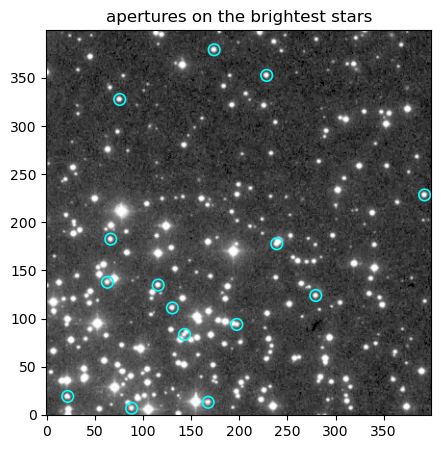

In [6]:
from matplotlib.patches import Circle
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(data, origin="lower", cmap="gray", norm=simple_norm(data,"sqrt",percent=99.5))
for xi, yi in pos:
    ax.add_patch(Circle((xi,yi), 6.0, ec="cyan", fc="none", lw=1.2))
ax.set_title("apertures on the brightest stars"); plt.show()

## Result

Our hand-rolled aperture photometry reproduces `photutils` **exactly** on a real CCD
image, and recovers known relative magnitudes on synthetic stars (see
`tests/test_photometry.py`). Instrumental magnitudes for the brightest M67 stars are
~11 (uncalibrated zero point). See `notes/HANDOFF_photometry.md`.